In [1]:
from pathlib import Path
import sys
import warnings
import os
import gc

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.ops import MLP
import torch.optim as optim
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, StratifiedKFold
from torch.utils.data import Dataset, TensorDataset, DataLoader, Subset
import optuna
from optuna.samplers import TPESampler

import random
import math
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import anndata
from anndata import AnnData
import pickle

sys.path.insert(0, "../../")

import scgpt as scg
from scgpt.tokenizer import GeneVocab
from scgpt import logger

warnings.filterwarnings("ignore", category=ResourceWarning)

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    
seed = 13
seed_everything(seed)

/home/harshil.sharma/miniconda3/envs/gene2ephys/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/allen/programs/mindscope/workgroups/auto-model/harshil.sharma/TransformerEphysPrediction/Human/Data Preprocessing/../../scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/allen/programs/mindscope/workgroups/auto-model/harshil.sharma/TransformerEphysPrediction/Human/Data Preprocessing/../../scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


In [2]:
# get adata for L2/3 dataset
l23_transcription_df = pd.read_csv("human_patchseq_L23_transcriptomicdata.csv", index_col=0)  # 50281 rows x 385 columns, rows are genes, columns are cells
l23_adata = AnnData(X=np.log1p(l23_transcription_df.values.T),obs=pd.DataFrame(index=l23_transcription_df.columns), var=pd.DataFrame(index=l23_transcription_df.index))  # AnnData wants cells as rows & genes in columns

l23_anno_df = pd.read_csv("human_patchseq_L23_annoData.csv")  # currently cells are named with "sample_id" column in this csv & in adata, we need "SpecimenID" for ephys data extraction
l23_adata.obs["SpecimenID"] = l23_anno_df["SpecimenID"].values

# get adata for L1 dataset
l1_transcription_df = pd.read_csv("human_patchseq_L1_transcriptomicData.csv", index_col=0)  # 50281 rows x 404 columns, rows are genes, columns are cells
l1_adata = AnnData(X=np.log1p(l1_transcription_df.values.T),obs=pd.DataFrame(index=l1_transcription_df.columns), var=pd.DataFrame(index=l1_transcription_df.index))  # AnnData wants cells as rows & genes in columns

l1anno_df = pd.read_csv("human_patchseq_L1_annoData.csv", index_col=0)  # currently cells are named with "sample_id" column in this csv & in adata, we need "spec_id_label" for ephys data extraction
l1_adata.obs["SpecimenID"] = l1anno_df["spec_id_label"].values

# combine both adata objects
combined_adata = anndata.concat([l23_adata, l1_adata], axis=0, join="outer", merge="unique")

# now select for the subset of our 50281 genes that are actually in scGPT vocabulary
model_dir = "../../scGPT_brain"
model_dir = Path(model_dir)
vocab_file = model_dir / "vocab.json"

vocab = GeneVocab.from_file(vocab_file)
combined_adata.var["id_in_vocab"] = [
    vocab[gene] if gene in vocab else -1 for gene in combined_adata.var.index
]
gene_ids_in_vocab = np.array(combined_adata.var["id_in_vocab"])
combined_adata = combined_adata[:, combined_adata.var["id_in_vocab"] >= 0]
combined_adata.var.drop(columns=["id_in_vocab"], inplace=True)

# get the ephys data
# first for L2/3
l23_ephys_df = pd.read_csv("patchseq_L23_ephys.csv") 
human_l23_specimen_ids = l23_adata.obs["SpecimenID"]
l23_ephys_df = l23_ephys_df[l23_ephys_df["specimen_id"].isin(human_l23_specimen_ids)]  # l23_ephys_df has both human and mouse specimens, so filter by SpecimenID in adata

# now for L1
l1_ephys_df = pd.read_csv("human_patchseq_L1_ephys.csv")
human_l1_specimen_ids = l1_adata.obs["SpecimenID"]
l1_ephys_df = l1_ephys_df[l1_ephys_df["cell_name"].isin(human_l1_specimen_ids)]  # filter for cells with transcriptomic data
l1_ephys_df = l1_ephys_df.rename(columns={"cell_name": "specimen_id"})  # for easier concatenating of both ephys dataframes

# the l1_ephys_df has columns (parameters) not in the l23_ephys_df, so filter those out
ephys_params_in_common = [col for col in l1_ephys_df.columns if col in l23_ephys_df.columns]
l1_ephys_df = l1_ephys_df[ephys_params_in_common]
l23_ephys_df = l23_ephys_df[ephys_params_in_common]

# combine the two ephys df
combined_ephys_df = pd.concat([l1_ephys_df, l23_ephys_df], ignore_index=True)
combined_ephys_df = combined_ephys_df.dropna(how="any")  # drop NaN containing rows

# filter for cells in adata that actually have ephys data
combined_ephys_df_ids = combined_ephys_df["specimen_id"]
mask = combined_adata.obs["SpecimenID"].isin(combined_ephys_df_ids)
combined_adata = combined_adata[mask].copy()

# combined_ephys_df has "specimen_id" in a different row ordering than combined_adata's "SpecimenID," we need them to be the same:
combined_ephys_df = combined_ephys_df.set_index("specimen_id")
combined_ephys_df = combined_ephys_df.reindex(combined_adata.obs["SpecimenID"])
combined_ephys_df = combined_ephys_df.reset_index()

combined_ephys_df.drop(columns=["latency_rheo"], inplace=True)  # poor predictability

# rename ephys features from raw_name to full_name
ephys_feature_names = pd.read_csv("ephys_feature_names.csv")
name_mapping = dict(zip(ephys_feature_names["raw_name"], ephys_feature_names["full_name"]))
combined_ephys_df.rename(columns=name_mapping, inplace=True)

# label the top 512 highly variable genes
sc.pp.highly_variable_genes(combined_adata, n_top_genes=512)

# Get one-hot encodings for each cell based on their Seurat cell type
l1_celltypes_df = pd.read_csv("human_patchseq_L1_metadata.csv")
l23_celltypes_df = pd.read_csv("human_patchseq_L23_metadata.csv")
celltypes_df = pd.concat([l1_celltypes_df, l23_ephys_df], ignore_index=True)
l1_celltypes_df = l1_celltypes_df.rename(columns={"spec_id": "SpecimenID", "seurat_cluster": "SeuratMapping"})  # to match the column names of interest in l23_celltypes_df

# only take Seurat cell type and SpecimenID columns
l1_celltypes_df = l1_celltypes_df[["SpecimenID", "SeuratMapping"]]
l23_celltypes_df = l23_celltypes_df[["SpecimenID", "SeuratMapping"]]
celltypes_df = pd.concat([l1_celltypes_df, l23_celltypes_df], ignore_index=True)

celltypes_df = celltypes_df[celltypes_df["SpecimenID"].isin(combined_adata.obs["SpecimenID"])]  # filter for the cells we are using

# drop cells which are in cell types that have less than 4 cells, and update ephys data & adata accordingly
cell_counts_per_type = celltypes_df["SeuratMapping"].value_counts()
valid_cells = cell_counts_per_type[cell_counts_per_type >= 4].index

celltypes_df_filtered = celltypes_df[celltypes_df["SeuratMapping"].isin(valid_cells)]

dropped = celltypes_df[~celltypes_df["SeuratMapping"].isin(valid_cells)]
dropped_specimen_ids = dropped["SpecimenID"].tolist()

combined_ephys_df = combined_ephys_df[~combined_ephys_df["SpecimenID"].isin(dropped_specimen_ids)]
print(combined_ephys_df)
print("-"*125)
combined_adata = combined_adata[~combined_adata.obs["SpecimenID"].isin(dropped_specimen_ids)].copy()

specimen_to_celltype = celltypes_df_filtered.set_index("SpecimenID")["SeuratMapping"].to_dict()  # make it a dictionary of SpecimenID : cell type

unique_celltypes = celltypes_df_filtered["SeuratMapping"].unique().tolist()  # this list will be used to map a cell's type to a one hot vector (follows the order of this list)
print(unique_celltypes)
print("Number of Unique Seurat Cell Types in our set of cells (list above):", len(unique_celltypes))
print("-"*125)

# Generate one-hot cell types
encoding_matrix = np.zeros((combined_adata.n_obs, len(unique_celltypes)), dtype=int)
for i, SpecimenID in enumerate(combined_adata.obs["SpecimenID"]):
    cell_type = specimen_to_celltype[SpecimenID]
    # Find the index of the cell type in the ordered list and set the corresponding position to 1
    cell_type_index = unique_celltypes.index(cell_type)
    encoding_matrix[i, cell_type_index] = 1
combined_adata.obsm["OneHotCellType"] = encoding_matrix

types = []
for SpecimenID in combined_adata.obs["SpecimenID"]:
    types.append(specimen_to_celltype[SpecimenID])
combined_adata.obs["CellType"] = types

# percentile the combined_ephys_df values by column (expect for SpecimenID which should be unchanged)
raw_ephys_df = combined_ephys_df.copy()
cols_to_standardize = combined_ephys_df.columns.difference(["SpecimenID"])
combined_ephys_df[cols_to_standardize] = combined_ephys_df[cols_to_standardize].rank(pct=True)

print(combined_adata)

     SpecimenID       sag  resting membrane potential    rheobase  f-I slope  \
0     541549258  0.031193                  -68.778985  170.000000   0.004053   
1     541557114  0.043156                  -70.443735  220.000000   0.021537   
2     569835804  0.055736                  -80.312557  110.000000   0.073350   
3     571511167  0.090862                  -72.592708   70.000000   0.118730   
4     571640763  0.013199                  -60.348639   40.000000   0.180672   
..          ...       ...                         ...         ...        ...   
493   832712819  0.317361                  -63.053950   29.999998   0.352941   
494   868240930  0.050562                  -67.351589   20.000000   0.595000   
496   595597625  0.067271                  -68.427370   10.000000   0.422586   
497   611610593  0.052174                  -60.569354   10.000000   0.421845   
499   880463055  0.152484                  -66.865382   59.999996   0.220000   

     input resistance  time constant τ 

In [3]:
# identify ion channel genes
ion_channel_genes = pd.read_csv("ion_channel_genes.csv")
ion_channel_genes = ion_channel_genes["Approved symbol"].tolist()

# we only want the list to contain ion channel genes that are also in cell_embeddings_adata's gene set
adata_gene_names = combined_adata.var_names.tolist()
ion_channel_genes_set = set(ion_channel_genes)
adata_gene_names_set = set(adata_gene_names)
common_genes = ion_channel_genes_set.intersection(adata_gene_names_set)

ion_channel_genes = list(common_genes)
print("Number of ion channel genes in vocab:", len(ion_channel_genes))
hvgset = set(combined_adata[:, combined_adata.var["highly_variable"]].var_names.tolist())
print("Of those ion channel genes, number also highly variable:",len(set(ion_channel_genes).intersection(hvgset)))

combined_adata.var["Ion channel coding"] = combined_adata.var_names.isin(ion_channel_genes)

Number of ion channel genes in vocab: 328
Of those ion channel genes, number also highly variable: 9


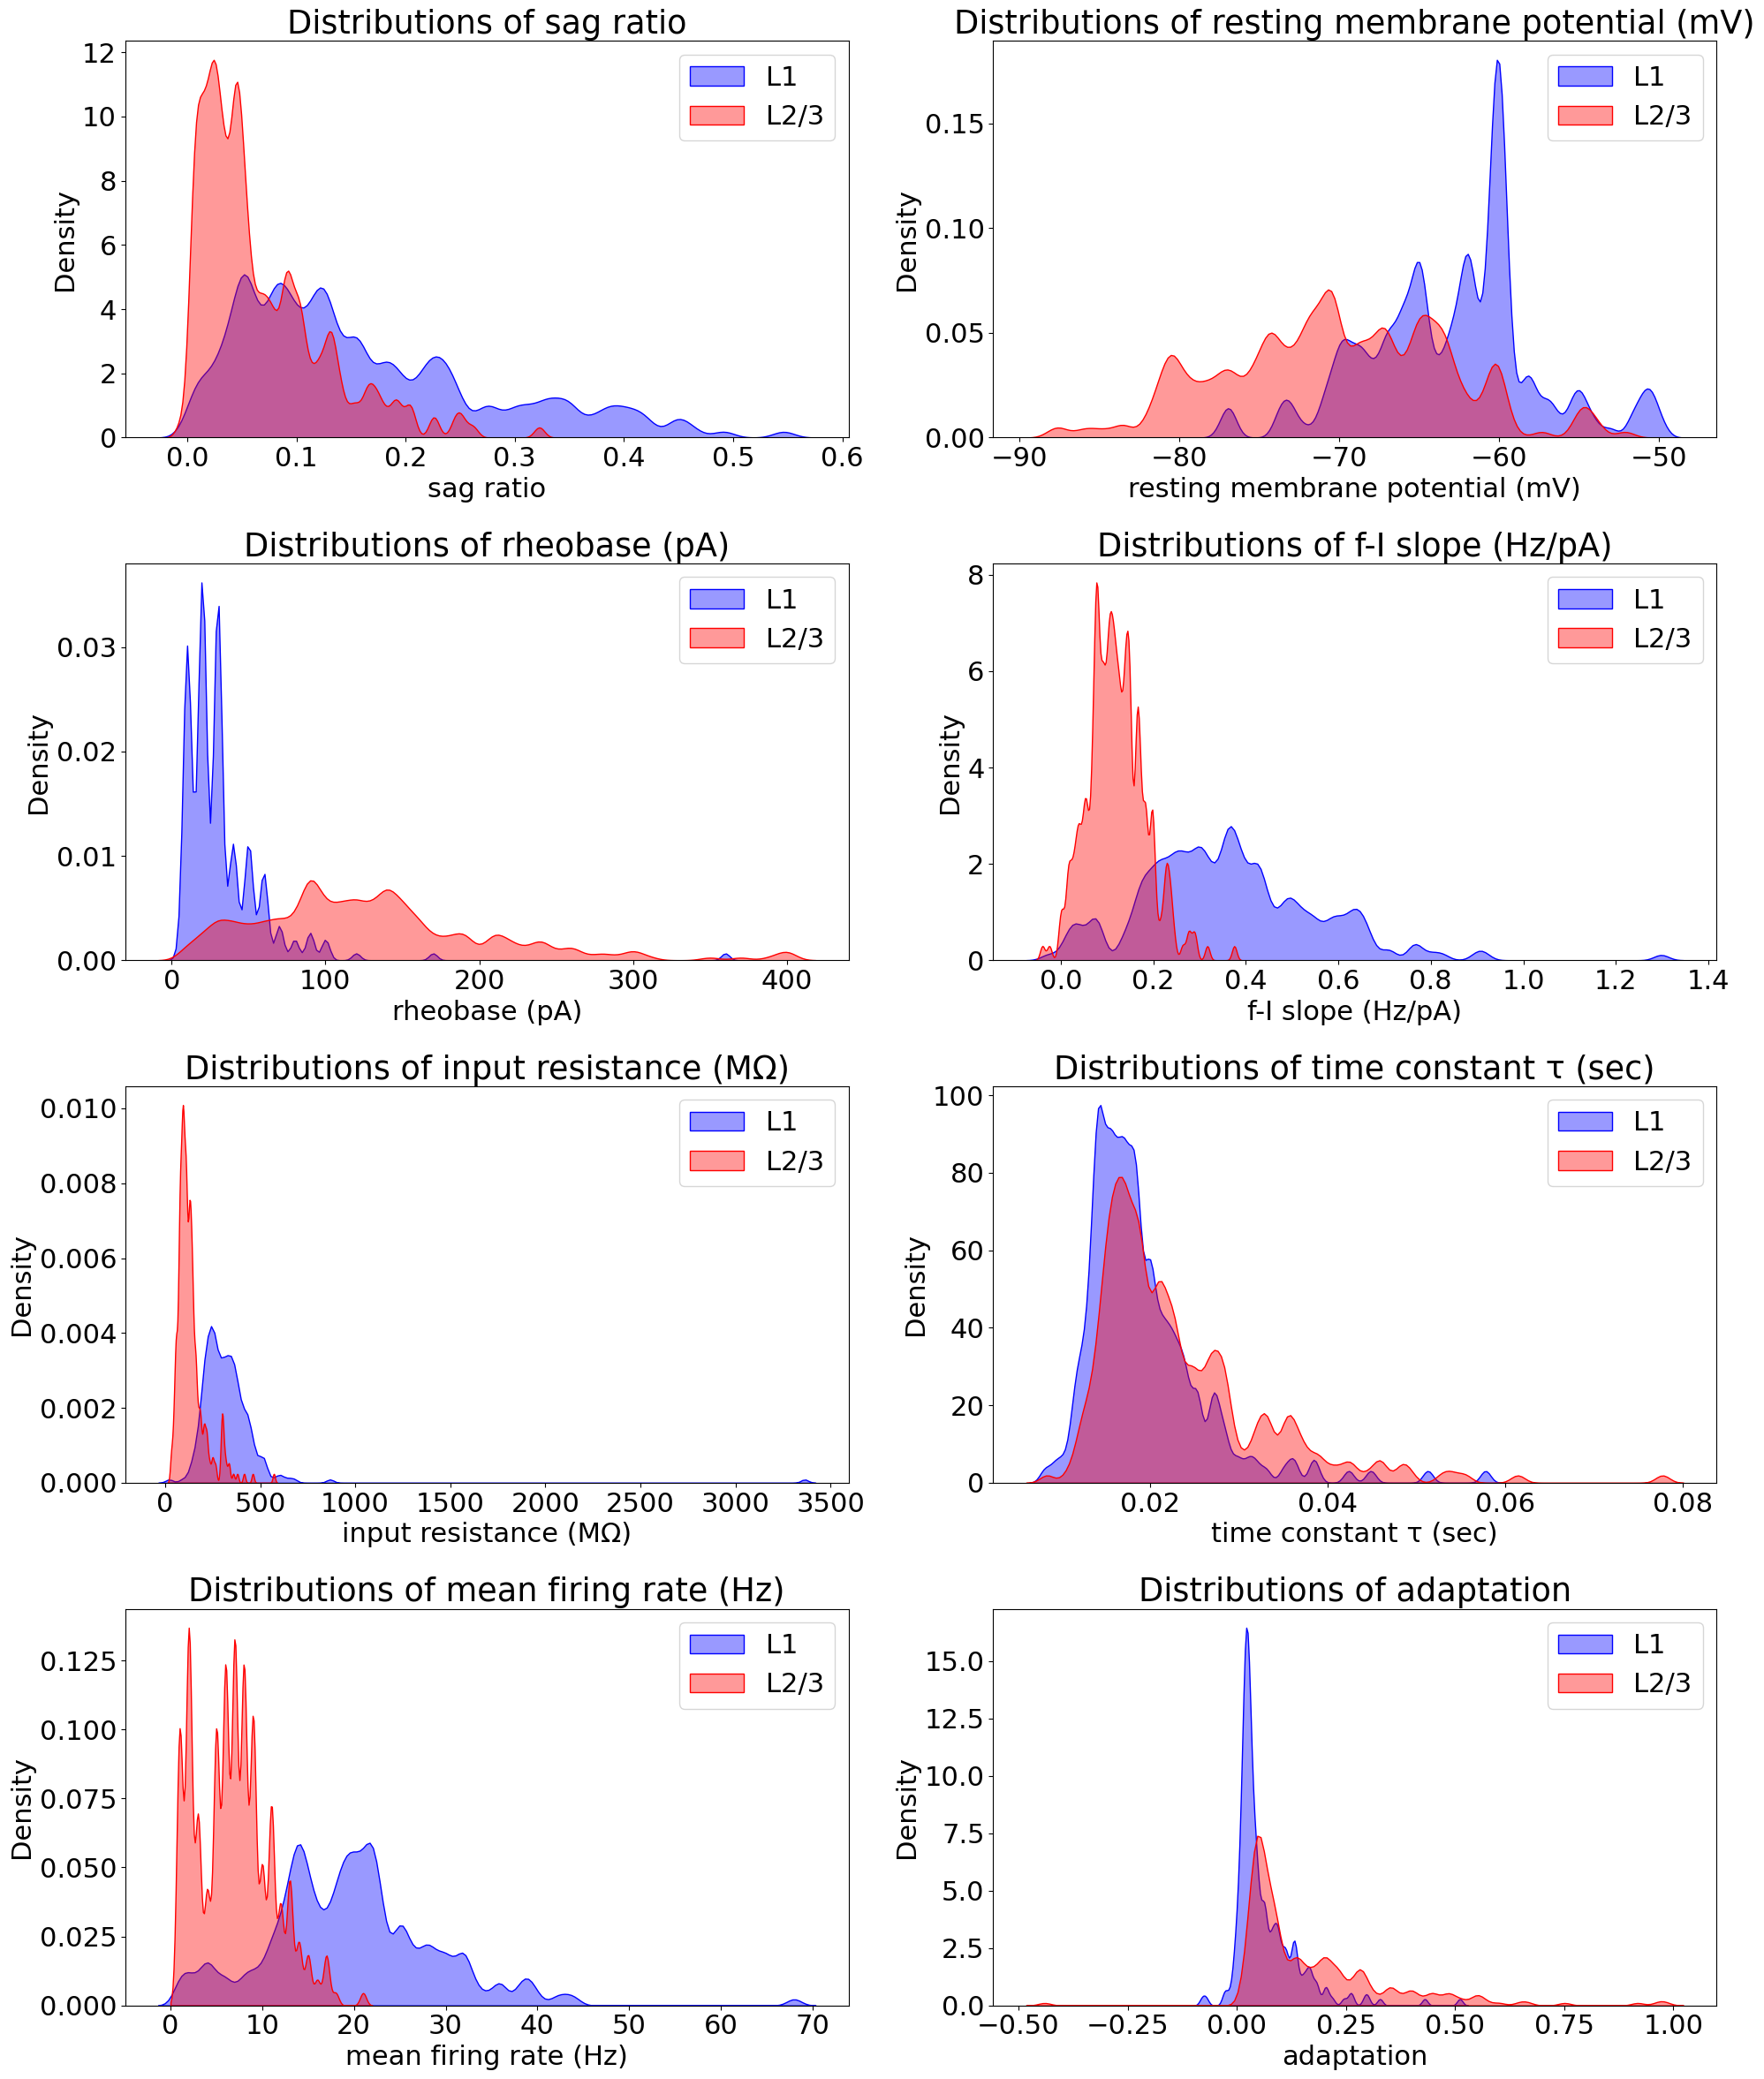

In [4]:
# visualize raw ephys feature distributions L1 & L2/3
plt.rcParams.update({'font.size': 22})
raw_ephys_df["Origin"] = "Unknown"  # Initialize with "Unknown"
raw_ephys_df.loc[raw_ephys_df["SpecimenID"].isin(l1_ephys_df["specimen_id"]), "Origin"] = "l1"
raw_ephys_df.loc[raw_ephys_df["SpecimenID"].isin(l23_ephys_df["specimen_id"]), "Origin"] = "l23"

# use units_name
name_mapping = dict(zip(ephys_feature_names["full_name"], ephys_feature_names["units_name"]))
raw_ephys_df.rename(columns=name_mapping, inplace=True)

params = raw_ephys_df.columns[1:-1]  # Exclude "SpecimenID" and "Origin"

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 24))  # 4 rows, 2 columns, larger figure size
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, param in enumerate(params):
    ax = axes[i]
    l1_data = raw_ephys_df[raw_ephys_df["Origin"] == "l1"][param]
    l23_data = raw_ephys_df[raw_ephys_df["Origin"] == "l23"][param]
    
    combined_data = np.concatenate([l1_data, l23_data])
    bin_edges = np.linspace(np.min(combined_data), np.max(combined_data), 101)  # 100 bins

    sns.kdeplot(l1_data, color="blue", label="L1", fill=True, alpha=0.4, bw_adjust=0.25, ax=ax)
    sns.kdeplot(l23_data, color="red", label="L2/3", fill=True, alpha=0.4, bw_adjust=0.25, ax=ax)
    
    ax.set_xlabel(param)
    ax.set_ylabel("Density")
    ax.set_title(f"Distributions of {param}")
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
counts = raw_ephys_df['Origin'].value_counts()
print(counts)

Origin
l23    266
l1     229
Name: count, dtype: int64


In [6]:
torch.cuda.set_per_process_memory_fraction(1.0, device=0)

In [7]:
# use scgpt to compute cell embeddings, updates combined_adata to cell_embeddings_adata with cell_embeddings_adata.obsm["X_scGPT"] containing the cell embeddings
cell_embeddings_adata = scg.tasks.embed_data(
    combined_adata,
    model_dir,
    gene_col="index",
    max_length=30683,
    batch_size=5,
    use_fast_transformer=False
)

scGPT - INFO - match 30682/30682 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 99/99 [01:27<00:00,  1.13it/s]
/allen/programs/mindscope/workgroups/auto-model/harshil.sharma/TransformerEphysPrediction/Human/Data Preprocessing/../../scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [8]:
print(cell_embeddings_adata)
print("-"*125)
print(combined_ephys_df)

AnnData object with n_obs × n_vars = 495 × 30682
    obs: 'SpecimenID', 'CellType'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Ion channel coding', 'index', 'id_in_vocab'
    uns: 'hvg'
    obsm: 'OneHotCellType', 'X_scGPT'
-----------------------------------------------------------------------------------------------------------------------------
     SpecimenID       sag  resting membrane potential  rheobase  f-I slope  \
0     541549258  0.206061                    0.379798  0.874747   0.014141   
1     541557114  0.278788                    0.303030  0.935354   0.034343   
2     569835804  0.389899                    0.046465  0.696970   0.137374   
3     571511167  0.543434                    0.214141  0.546465   0.321212   
4     571640763  0.078788                    0.797980  0.400000   0.519192   
..          ...       ...                         ...       ...        ...   
493   832712819  0.937374                    0.676768  0.294949   0.769697 

In [9]:
cell_embeddings_adata.write_h5ad(filename="cell_embeddings_adata.h5ad")
combined_ephys_df.to_pickle("combined_ephys_df.pkl")